# Z-Distribution <hr style="border: 2.5px solid; color: #d020b0ff"></hr>

<b>Axel Nazir M. Belnas</b>
<br>3rd year</br>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv(r"datasets\transformer-voltage.csv", delimiter=",", index_col='Sample')
df

,Voltage
Sample,
1,117.0
2,118.3
3,119.5
4,119.5
5,119.6
6,119.6
7,119.7
8,119.7
9,119.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  30 non-null     float64
dtypes: float64(1)
memory usage: 480.0 bytes


In [4]:
df.describe()

,Voltage
count,30.000000
mean,120.290000
std,1.243285
min,117.000000
25%,119.700000
50%,120.100000
75%,120.500000
max,123.800000


In [5]:
alpha = 0.05

z_critical = stats.norm.ppf(1-alpha/2)
z_critical

np.float64(1.959963984540054)

In [10]:
pop_std = 5

ci_lower, ci_upper = stats.norm.interval(
    confidence=0.95,
    loc = df['Voltage'].mean(),
    scale = pop_std/np.sqrt(df['Voltage'].count())
)

print(f"CI: [{ci_lower:.2f}, {ci_upper:.2f}]")

CI: [118.50, 122.08]


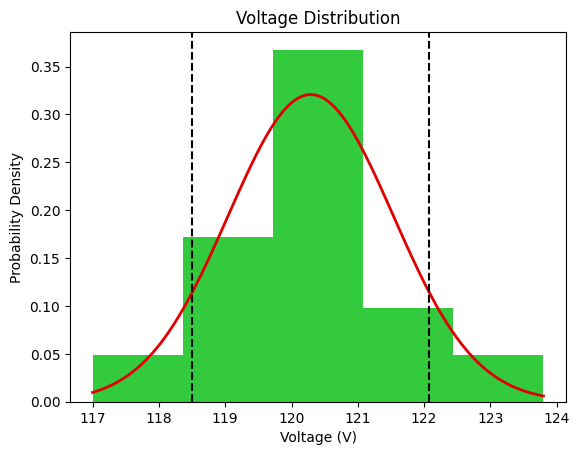

In [20]:
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

x = np.linspace(x_min,x_max,100)
p = stats.norm.pdf(x,mean,std)
plt.plot(x,p,
         linewidth=2,
         color="#E00000")
plt.title("Voltage Distribution")
plt.xlabel("Voltage (V)")
plt.ylabel("Probability Density")
plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color="#00BD0D")
plt.axvline(x=ci_lower,
            color='#000000',
            linestyle='--')
plt.axvline(x=ci_upper,
            color='#000000',
            linestyle='--')
plt.show()